In [13]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm
import seaborn as sns

from scipy.stats import norm, lognorm, pearsonr
from sklearn.metrics import r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf



sys.path.append("../")
from xThreat import xThreat

# Import data

In [14]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../3-calculate-values/model-error-distribution/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../3-calculate-values/model-error-distribution/bootstrap_errors_normal_xthreat_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']

In [15]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# Study influences

In [43]:
y_col = 'xT_error_inf_norm'
x_cols = ['transition_matrix_error_inf_norm', 'weighted_transition_matrix_error_inf_norm',
                            'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
y_label = r'Model error ($||xT-\widehat{xT}||_\infty$)'
x_labels = [r'Transition matrix error ($||T-\widehat{T}||_\infty$)', 
            r'Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$)',
            r'Goal probability error ($||g-\widehat{g}||_\infty$)', 
            r'Expected goals error ($||xG-\widehat{xG}||_\inf$)', 
            r'Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$)',
            ]

In [44]:
sns.set(style="whitegrid")

R^2 between Transition matrix error ($||T-\widehat{T}||_\infty$) and model error: 0.6510
R^2 between Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$) and model error: 0.6511
R^2 between Goal probability error ($||g-\widehat{g}||_\infty$) and model error: 0.9870
R^2 between Expected goals error ($||xG-\widehat{xG}||_\inf$) and model error: 0.2507
R^2 between Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$) and model error: 0.9124


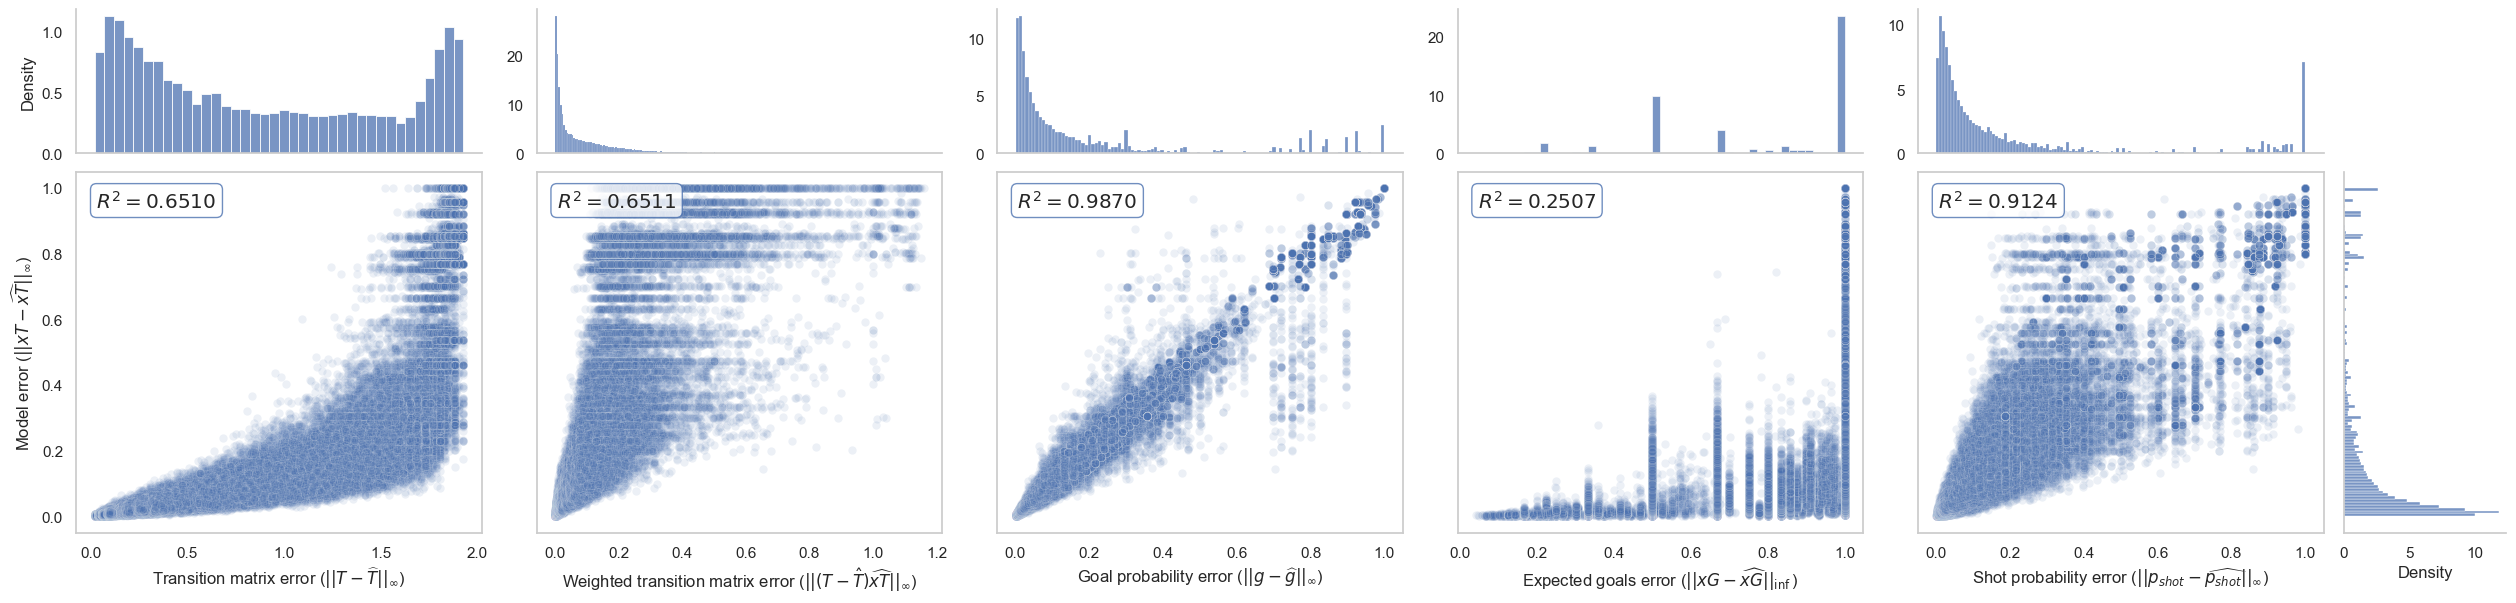

In [45]:
# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # R^2 annotation 
    ax.text( 0.05, 0.95, 
            f"$R^2 = {r2:.4f}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
            ) 

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($||xT-\widehat{xT}||_\infty$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.40]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    if idx > 0:
        ax_hist_above.set_ylabel('')
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.grid(False) 
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
plt.tight_layout() 
plt.show()

R^2 between Transition matrix error ($||T-\widehat{T}||_\infty$) and model error: 0.6510
R^2 between Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$) and model error: 0.6511
R^2 between Goal probability error ($||g-\widehat{g}||_\infty$) and model error: 0.9870
R^2 between Expected goals error ($||xG-\widehat{xG}||_\inf$) and model error: 0.2507
R^2 between Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$) and model error: 0.9124


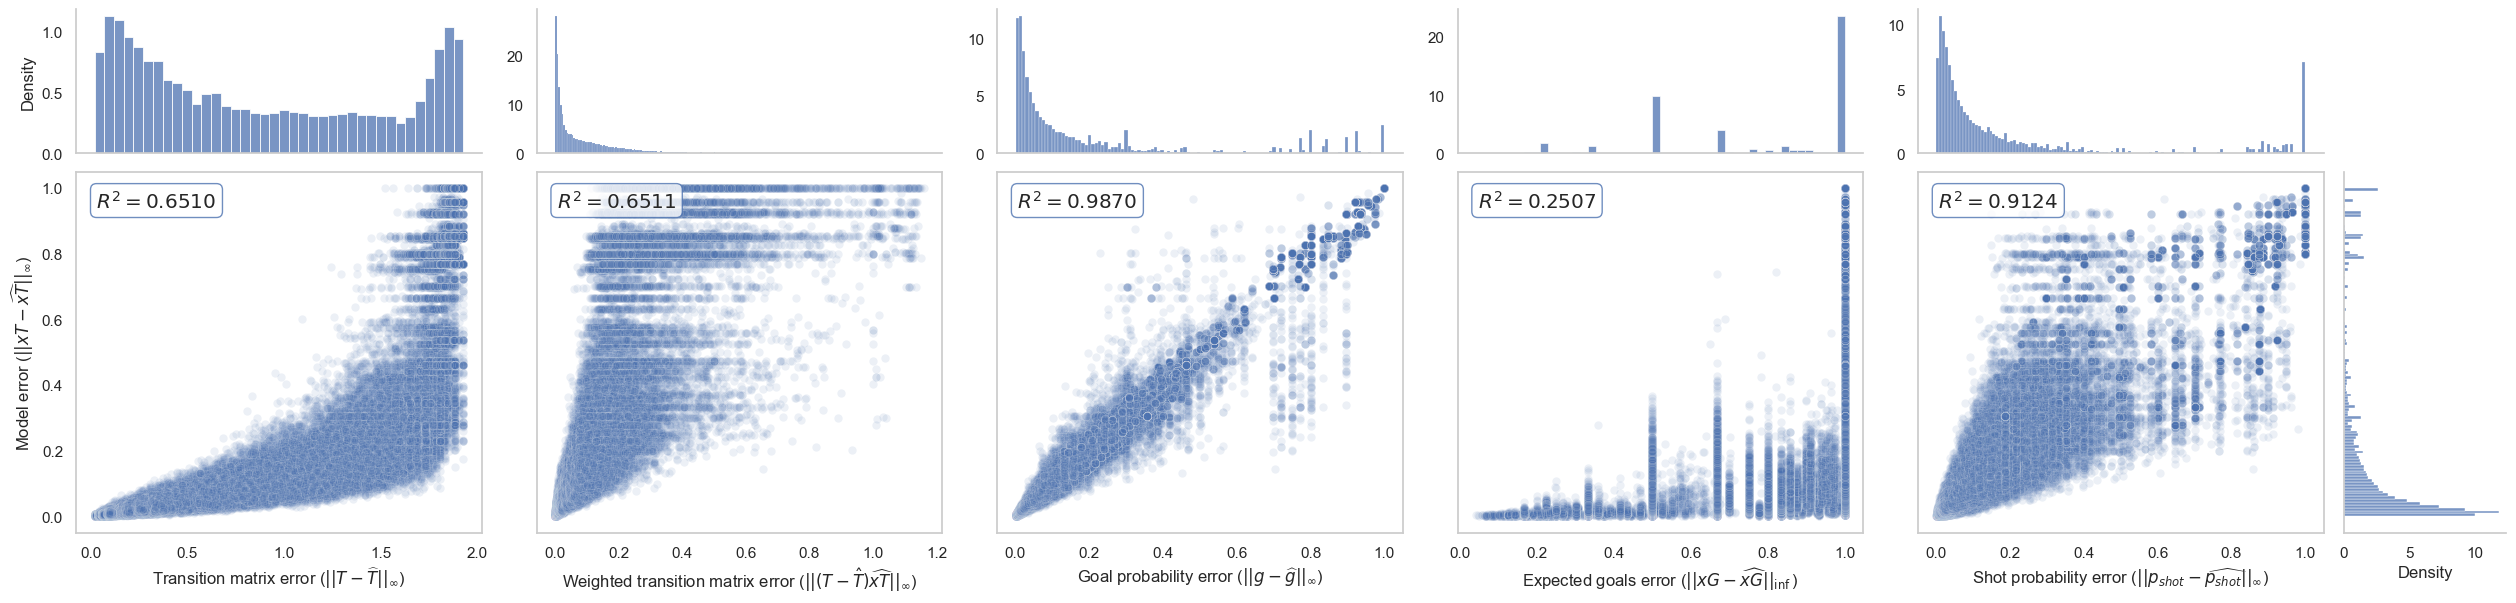

In [46]:
# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # R^2 annotation 
    ax.text( 0.05, 0.95, 
            f"$R^2 = {r2:.4f}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
            ) 

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($||xT-\widehat{xT}||_\infty$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.40]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.grid(False) 
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
plt.tight_layout() 
plt.show()

In [ ]:
# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # R^2 annotation 
    ax.text( 0.05, 0.95, 
            f"$R^2 = {r2:.4f}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
            ) 

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($||xT-\widehat{xT}||_\infty$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.40]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.grid(False) 
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
plt.tight_layout() 
plt.show()

<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_22312\878329980.py:60: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes,


R^2 between Weighted transition matrix error ($\mathbf{{||(T-\hat{T})\widehat{xT}||_\infty}}$) and model error: 0.6511
R^2 between Goal probability error ($\mathbf{{||g-\widehat{g}||_\infty}}$) and model error: 0.9870


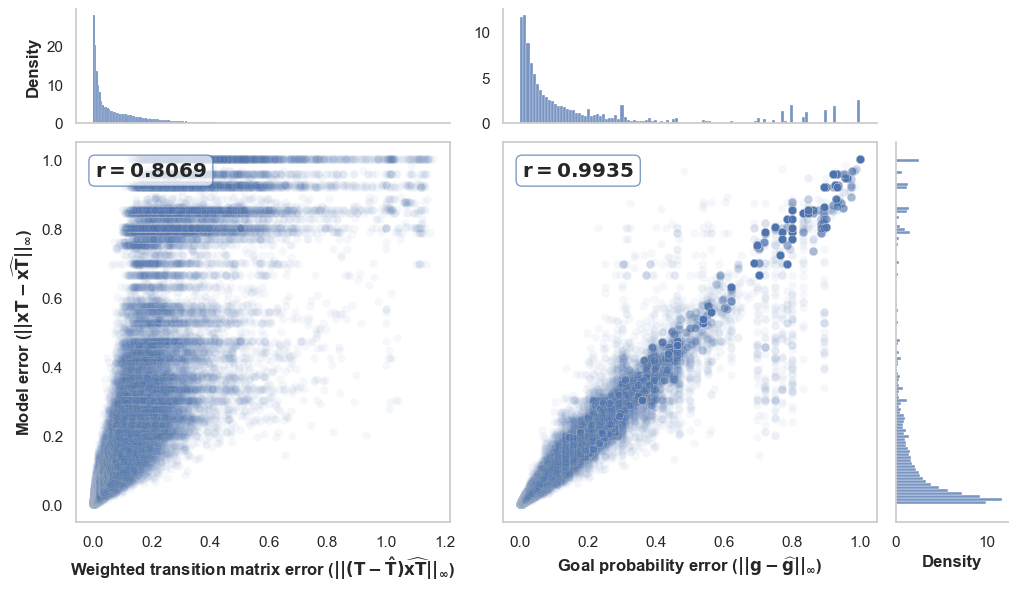

In [61]:
y_col = 'xT_error_inf_norm'
x_cols = [
    # 'transition_matrix_error_inf_norm', 
    'weighted_transition_matrix_error_inf_norm',
    'g_error_inf_norm', 
    # 'xG_error_inf_norm', 
    # 'prob_shot_error_inf_norm',
    ]
y_label = r'Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$)'
x_labels = [
    # r'Transition matrix error ($\mathbf{{||T-\widehat{T}||_\infty}}$)', 
    r'Weighted transition matrix error ($\mathbf{{||(T-\hat{T})\widehat{xT}||_\infty}}$)',
    r'Goal probability error ($\mathbf{{||g-\widehat{g}||_\infty}}$)', 
    # r'Expected goals error ($\mathbf{{||xG-\widehat{xG}||_\infty}}$)', 
    # r'Shot probability error ($\mathbf{{||p_{shot}-\widehat{p_{shot}}||_\infty}}$)',
    ]

hist_size = 0.30

# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols+hist_size, 5*(1+hist_size)), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    # sns.scatterplot(x=x, y=y, ax=ax, alpha=0.01, s=8) 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.05) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # # R^2 annotation 
    # ax.text( 0.05, 0.95, 
    #         f"$\mathbf{{R^2 = {r2:.4f}}}$", transform=ax.transAxes, 
    #         ha='left', va='top', 
    #         fontsize='large', fontweight='extra bold',
    #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
    #         ) 

    # Annotate the pearson correlation coefficient instead
    pearson_corr, _ = pearsonr(x, y)
    ax.text( 0.05, 0.95, 
            f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor=hist_color)
            )

    # Axis labels 
    ax.set_xlabel(label, fontweight='bold') 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$)', fontweight='bold') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.30]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.set_ylabel('Density', fontweight='bold')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.30, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        ax_hist.set_xlabel('Density', fontweight='bold')
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
        ax_hist.grid(False) 
plt.tight_layout() 
plt.show()

<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_22312\1428000505.py:60: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes,


R^2 between Weighted transition matrix error (${||(T-\hat{T})\widehat{xT}||_\infty}$) and model error: 0.6511
R^2 between Goal probability error (${||g-\widehat{g}||_\infty}$) and model error: 0.9870


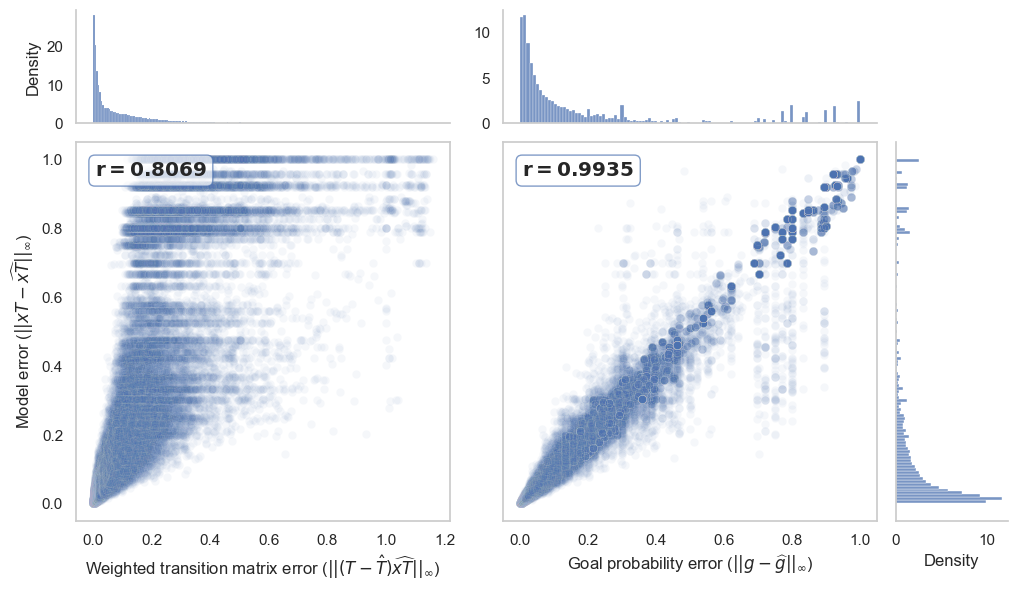

In [63]:
y_col = 'xT_error_inf_norm'
x_cols = [
    # 'transition_matrix_error_inf_norm', 
    'weighted_transition_matrix_error_inf_norm',
    'g_error_inf_norm', 
    # 'xG_error_inf_norm', 
    # 'prob_shot_error_inf_norm',
    ]
y_label = r'Model error (${||xT-\widehat{xT}||_\infty}$)'
x_labels = [
    # r'Transition matrix error (${||T-\widehat{T}||_\infty}$)', 
    r'Weighted transition matrix error (${||(T-\hat{T})\widehat{xT}||_\infty}$)',
    r'Goal probability error (${||g-\widehat{g}||_\infty}$)', 
    # r'Expected goals error (${||xG-\widehat{xG}||_\infty}$)', 
    # r'Shot probability error (${||p_{shot}-\widehat{p_{shot}}||_\infty}$)',
    ]

hist_size = 0.30

# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols+hist_size, 5*(1+hist_size)), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    # sns.scatterplot(x=x, y=y, ax=ax, alpha=0.01, s=8) 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.05) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # # R^2 annotation 
    # ax.text( 0.05, 0.95, 
    #         f"$\mathbf{{R^2 = {r2:.4f}}}$", transform=ax.transAxes, 
    #         ha='left', va='top', 
    #         fontsize='large', fontweight='extra bold',
    #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
    #         ) 

    # Annotate the pearson correlation coefficient instead
    pearson_corr, _ = pearsonr(x, y)
    ax.text( 0.05, 0.95, 
            f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor=hist_color)
            )

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Model error (${||xT-\widehat{xT}||_\infty}$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.30]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.set_ylabel('Density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.30, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        ax_hist.set_xlabel('Density')
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
        ax_hist.grid(False) 
plt.tight_layout() 
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_22312\4158126390.py:49: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{R^2 = {r2:.4f}}}$", transform=ax.transAxes,


R^2 between Expected goals error ($\mathbf{{||xG-\widehat{xG}||_\infty}}$) and model error: 0.2507
R^2 between Shot probability error ($\mathbf{{||p_{shot}-\widehat{p_{shot}}||_\infty}}$) and model error: 0.9124


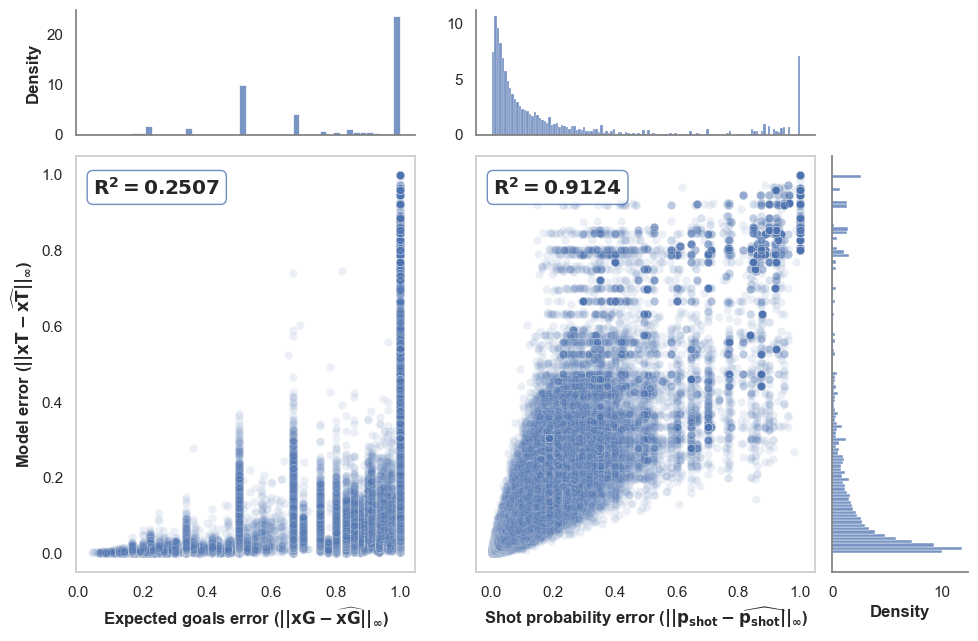

In [40]:
y_col = 'xT_error_inf_norm'
x_cols = [
    # 'transition_matrix_error_inf_norm', 
    # 'weighted_transition_matrix_error_inf_norm',
    # 'g_error_inf_norm', 
    'xG_error_inf_norm', 
    'prob_shot_error_inf_norm',
    ]
y_label = r'Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$)'
x_labels = [
    # r'Transition matrix error ($\mathbf{{||T-\widehat{T}||_\infty}}$)', 
    # r'Weighted transition matrix error ($\mathbf{{||(T-\hat{T})\widehat{xT}||_\infty}}$)',
    # r'Goal probability error ($\mathbf{{||g-\widehat{g}||_\infty}}$)', 
    r'Expected goals error ($\mathbf{{||xG-\widehat{xG}||_\infty}}$)', 
    r'Shot probability error ($\mathbf{{||p_{shot}-\widehat{p_{shot}}||_\infty}}$)',
    ]


# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # R^2 annotation 
    ax.text( 0.05, 0.95, 
            f"$\mathbf{{R^2 = {r2:.4f}}}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
            ) 

    # Axis labels 
    ax.set_xlabel(label, fontweight='bold') 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$)', fontweight='bold') 
    else: ax.set_ylabel('') 

    # ax.spines['left'].set_color('gray')
    # ax.spines['bottom'].set_color('gray')
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)



    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, hist_size]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.set_ylabel('Density', fontweight='bold')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)

    ax_hist_above.spines['left'].set_visible(True)
    ax_hist_above.spines['bottom'].set_visible(True)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)

    # Change color of the axes
    ax_hist_above.spines['left'].set_color('gray')
    ax_hist_above.spines['bottom'].set_color('gray')

    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        ax_hist.set_xlabel('Density', fontweight='bold')
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)

        # Make bounding box only on the left and bottom of the histogram, not on the right and top
        ax_hist.spines['left'].set_visible(True)
        ax_hist.spines['bottom'].set_visible(True)
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)

        # Change color of the axes
        ax_hist.spines['left'].set_color('gray')
        ax_hist.spines['bottom'].set_color('gray')


        ax_hist.grid(False) 
plt.tight_layout() 
plt.show()

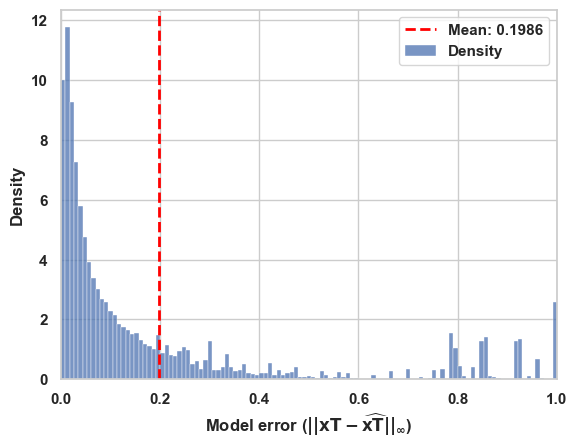

Mean error in Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$) is 0.19862348129596508.


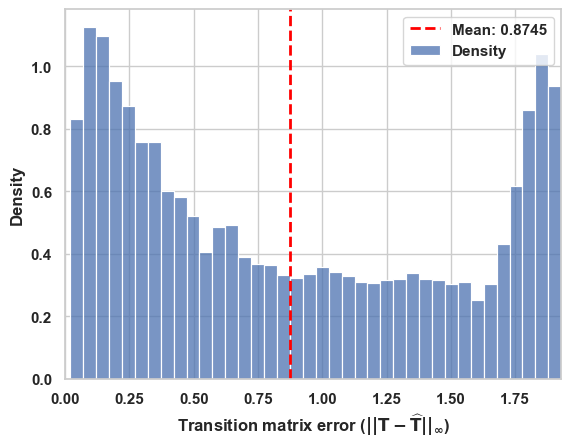

Mean error in Transition matrix error ($\mathbf{{||T-\widehat{T}||_\infty}}$) is 0.874458949470042.


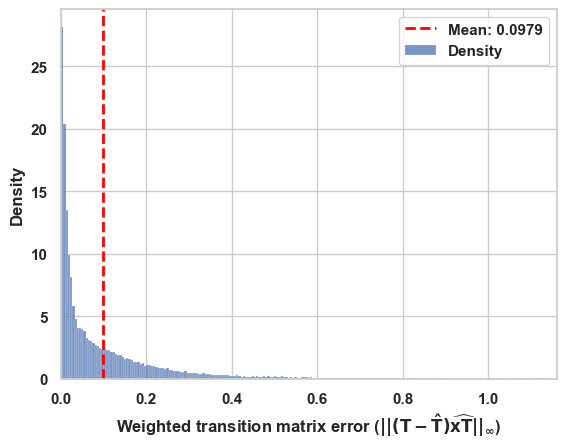

Mean error in Weighted transition matrix error ($\mathbf{{||(T-\hat{T})\widehat{xT}||_\infty}}$) is 0.0978855778167158.


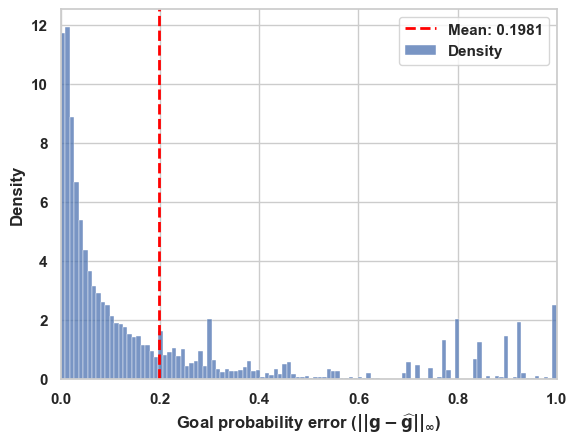

Mean error in Goal probability error ($\mathbf{{||g-\widehat{g}||_\infty}}$) is 0.1980938458847153.


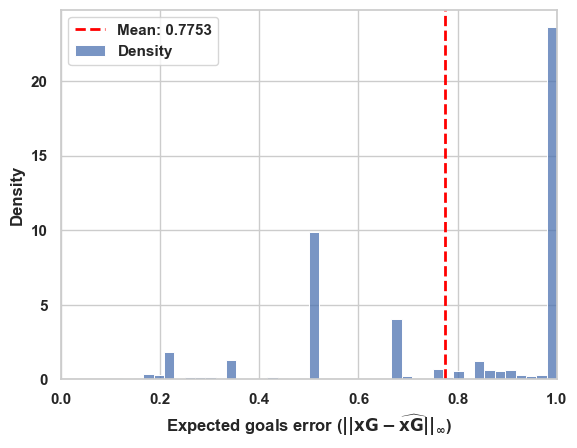

Mean error in Expected goals error ($\mathbf{{||xG-\widehat{xG}||_\infty}}$) is 0.775294950032889.


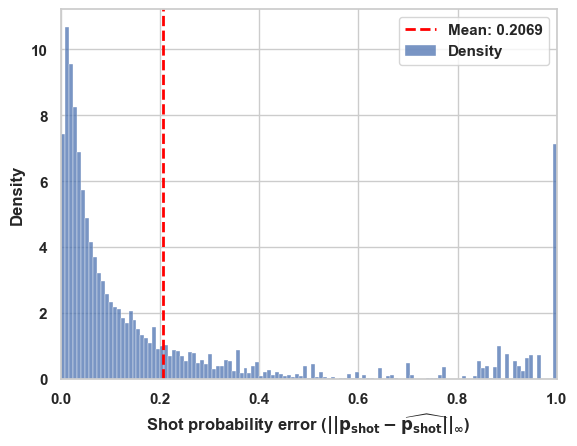

Mean error in Shot probability error ($\mathbf{{||p_{shot}-\widehat{p_{shot}}||_\infty}}$) is 0.20689918581649452.


In [66]:
# Plot histograms of the errors
error_columns = ['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 'weighted_transition_matrix_error_inf_norm',
                 'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
error_labels = [r'Model error ($\mathbf{{||xT-\widehat{xT}||_\infty}}$)', 
                r'Transition matrix error ($\mathbf{{||T-\widehat{T}||_\infty}}$)', 
                r'Weighted transition matrix error ($\mathbf{{||(T-\hat{T})\widehat{xT}||_\infty}}$)',
                r'Goal probability error ($\mathbf{{||g-\widehat{g}||_\infty}}$)', 
                r'Expected goals error ($\mathbf{{||xG-\widehat{xG}||_\infty}}$)', 
                r'Shot probability error ($\mathbf{{||p_{shot}-\widehat{p_{shot}}||_\infty}}$)', 
                r'Weighted shot probability error ($\mathbf{{||w_{shot}-\widehat{w_{shot}}||_\infty}}$)']

for error_col, error_label in zip(error_columns, error_labels):
    plt.figure()
    sns.histplot(df_errors[error_col], bins='auto', kde=False, stat='density', label='Density')
    # plt.title(f"Histogram of {error_label}")
    plt.xlabel(error_label, fontweight='bold')
    plt.ylabel("Density", fontweight='bold')
    plt.xlim(0, max(1.0, df_errors[error_col].max()))
    # Make the ticks bold
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    # Add the mean value as a vertical line
    mean_value = df_errors[error_col].mean()

    plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.4f}')
    # Make legend bold
    plt.legend()
    for label in plt.legend().get_texts():
        label.set_fontweight('bold')
    plt.show()
    print(f"Mean error in {error_label} is {df_errors[error_col].mean()}.")

## Add inf norm true matrix

In [10]:
# Create a dictionary to map the value of M to the true underlying ||T||_inf differently
M_to_true_inf_norm = {}

# Specify values of M and n_x, n_y to investigate
M_values = df_errors['M'].unique().tolist()
n_x_values = df_errors['n_x'].unique().tolist()
n_y_values = df_errors['n_y'].unique().tolist()

# sort both n_x and n_y to ensure they are in the same order as M
n_x_values.sort()
n_y_values.sort()
M_values.sort()



# Iterate over the unique values of M and find the corresponding true_inf_norm
for i, M in enumerate(M_values):
    n_x = n_x_values[i]
    n_y = n_y_values[i]
    # Load the ground truth models for the given M
    xT_ground_truth = xThreat.load_from_pickle(f"../2-train-models/model-storage/true-models/xt-full-data-n_x{n_x}-n_y{n_y}.pickle")

    # Get submatrix of all in-game states
    transition_matrix_true = xT_ground_truth.transition_matrix[:xT_ground_truth.n_game_states, :xT_ground_truth.n_game_states]

    # Compute the infinity norm of the true transition matrix
    true_inf_norm = np.linalg.norm(transition_matrix_true, ord=np.inf)
    M_to_true_inf_norm[M] = true_inf_norm

    
print(M_to_true_inf_norm)

{48: np.float64(0.9172553504817864), 80: np.float64(0.9176488365064976), 108: np.float64(0.9188261541101769), 154: np.float64(0.9202370915408395), 192: np.float64(0.9199613961717868), 300: np.float64(0.9214304496450171), 432: np.float64(0.9228862973760934), 588: np.float64(0.9249896822121338), 768: np.float64(0.9237630662020905), 1200: np.float64(0.9273863909593653), 1728: np.float64(0.928186109238031), 2352: np.float64(0.9325242718446601), 3072: np.float64(0.9761904761904762)}


In [6]:
import matplotlib.colors as mcolors
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde
from scipy.spatial import ConvexHull, Delaunay

base_color = sns.color_palette()[0]

R² for combined error: 0.7047
Pearson correlation: 0.8395 (p=0.0000)


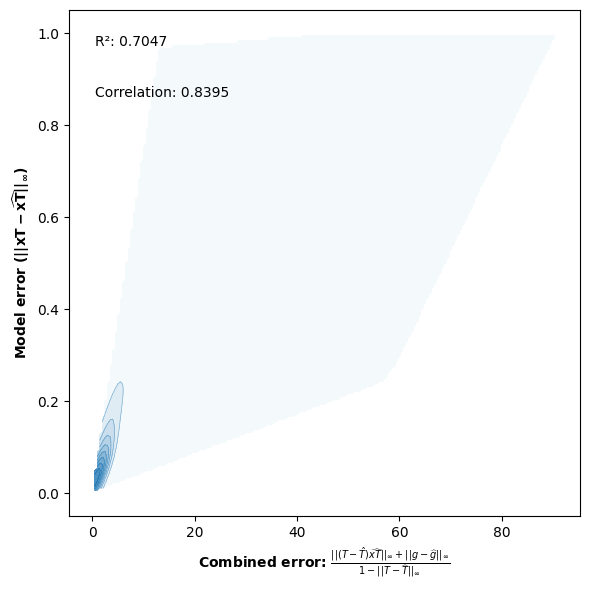

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(6,6))

df_errors['transition_submatrix_true_inf_norm'] = df_errors['M'].map(M_to_true_inf_norm)

Y = df_errors['xT_error_inf_norm'].values
X = (df_errors['weighted_transition_matrix_error_inf_norm'].values + df_errors['g_error_inf_norm'].values) / (1-df_errors['transition_submatrix_true_inf_norm'].values)

# Compute R²
coeffs = np.polyfit(X, Y, 1)
Y_pred = np.polyval(coeffs, X)
r2 = r2_score(Y, Y_pred)
print(f"R² for combined error: {r2:.4f}")

# Compute Pearson correlation
from scipy.stats import pearsonr
corr, p_value = pearsonr(X, Y)
print(f"Pearson correlation: {corr:.4f} (p={p_value:.4f})")

# KDE on a fine grid
xy = np.vstack([X, Y])
kde = gaussian_kde(xy, bw_method='scott')
x_min, x_max = X.min(), X.max()
y_min, y_max = Y.min(), Y.max()
x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

xi = np.linspace(x_min - x_pad, x_max + x_pad, 200)
yi = np.linspace(y_min - y_pad, y_max + y_pad, 200)

Xi, Yi = np.meshgrid(xi, yi)
grid_points = np.vstack([Xi.ravel(), Yi.ravel()]).T
Zi = kde(grid_points.T).reshape(Xi.shape)

# Convex hull mask
from scipy.spatial import ConvexHull, Delaunay
hull = ConvexHull(np.column_stack([X, Y]))
hull_check = Delaunay(np.column_stack([X, Y])[hull.vertices])
inside = hull_check.find_simplex(grid_points) >= 0
Zi_masked = np.where(inside.reshape(Xi.shape), Zi, np.nan)

# Filled contours
levels = np.linspace(Zi_masked[~np.isnan(Zi_masked)].min(),
                     Zi_masked[~np.isnan(Zi_masked)].max(), 10)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['white', base_color], N=256)
axes.contourf(Xi, Yi, Zi_masked, levels=levels, cmap=cmap, alpha=0.85)
axes.contour(Xi, Yi, Zi_masked, levels=levels[1:], colors=[base_color],
             linewidths=0.5, alpha=0.5)
axes.set_facecolor('white')
axes.grid(False)
axes.set_xlim(x_min - x_pad, x_max + x_pad)
axes.set_ylim(y_min - y_pad, y_max + y_pad)

# R² and correlation annotation

axes.text(0.05, 0.95, f"R²: {r2:.4f}", transform=axes.transAxes, verticalalignment='top')
axes.text(0.05, 0.85, f"Correlation: {corr:.4f}", transform=axes.transAxes, verticalalignment='top')
axes.set_xlabel(r'Combined error: $\frac{||(T-\hat{T})\widehat{xT}||_\infty + ||g-\widehat{g}||_\infty}{1 - ||T-\widehat{T}||_\infty}$', fontweight='bold')
axes.set_ylabel(r'Model error ($\mathbf{||xT-\widehat{xT}||_\infty}$)', fontweight='bold')
plt.tight_layout()
plt.show()


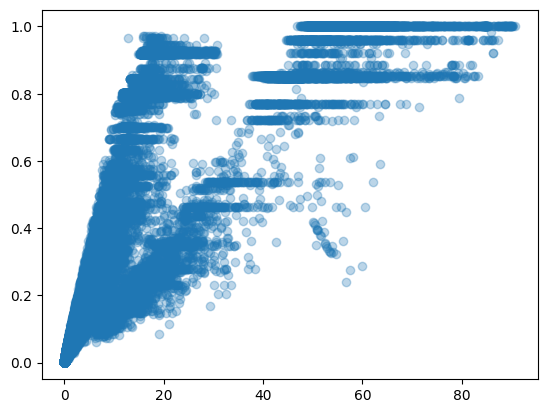

In [12]:
plt.scatter(X, Y, alpha=0.3, color=base_color)

R² for combined error: 0.9476
Pearson correlation: 0.9735 (p=0.0000)


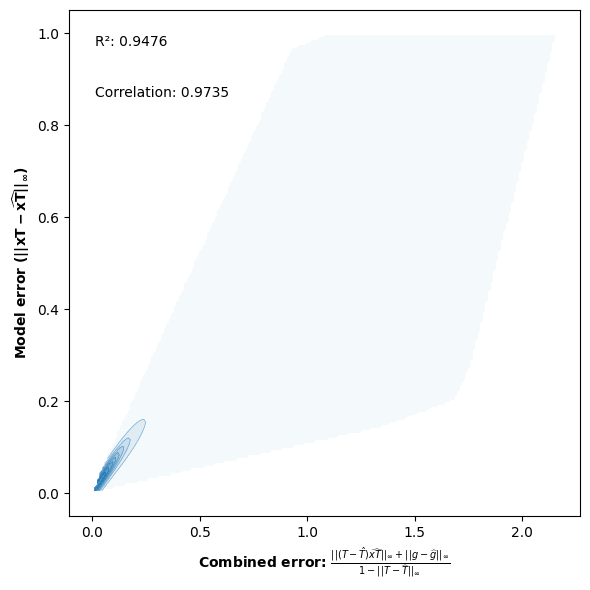

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(6,6))

Y = df_errors['xT_error_inf_norm'].values
X = df_errors['weighted_transition_matrix_error_inf_norm'].values + df_errors['g_error_inf_norm'].values

# Compute R²
coeffs = np.polyfit(X, Y, 1)
Y_pred = np.polyval(coeffs, X)
r2 = r2_score(Y, Y_pred)
print(f"R² for combined error: {r2:.4f}")

# Compute Pearson correlation
from scipy.stats import pearsonr
corr, p_value = pearsonr(X, Y)
print(f"Pearson correlation: {corr:.4f} (p={p_value:.4f})")

# KDE on a fine grid
xy = np.vstack([X, Y])
kde = gaussian_kde(xy, bw_method='scott')
x_min, x_max = X.min(), X.max()
y_min, y_max = Y.min(), Y.max()
x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

xi = np.linspace(x_min - x_pad, x_max + x_pad, 200)
yi = np.linspace(y_min - y_pad, y_max + y_pad, 200)

Xi, Yi = np.meshgrid(xi, yi)
grid_points = np.vstack([Xi.ravel(), Yi.ravel()]).T
Zi = kde(grid_points.T).reshape(Xi.shape)

# Convex hull mask
from scipy.spatial import ConvexHull, Delaunay
hull = ConvexHull(np.column_stack([X, Y]))
hull_check = Delaunay(np.column_stack([X, Y])[hull.vertices])
inside = hull_check.find_simplex(grid_points) >= 0
Zi_masked = np.where(inside.reshape(Xi.shape), Zi, np.nan)

# Filled contours
levels = np.linspace(Zi_masked[~np.isnan(Zi_masked)].min(),
                     Zi_masked[~np.isnan(Zi_masked)].max(), 10)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['white', base_color], N=256)
axes.contourf(Xi, Yi, Zi_masked, levels=levels, cmap=cmap, alpha=0.85)
axes.contour(Xi, Yi, Zi_masked, levels=levels[1:], colors=[base_color],
             linewidths=0.5, alpha=0.5)
axes.set_facecolor('white')
axes.grid(False)
axes.set_xlim(x_min - x_pad, x_max + x_pad)
axes.set_ylim(y_min - y_pad, y_max + y_pad)

# R² and correlation annotation

axes.text(0.05, 0.95, f"R²: {r2:.4f}", transform=axes.transAxes, verticalalignment='top')
axes.text(0.05, 0.85, f"Correlation: {corr:.4f}", transform=axes.transAxes, verticalalignment='top')
axes.set_xlabel(r'Combined error: $\frac{||(T-\hat{T})\widehat{xT}||_\infty + ||g-\widehat{g}||_\infty}{1 - ||T-\widehat{T}||_\infty}$', fontweight='bold')
axes.set_ylabel(r'Model error ($\mathbf{||xT-\widehat{xT}||_\infty}$)', fontweight='bold')
plt.tight_layout()
plt.show()
